Extracting features...
Feature extraction completed!
Feature DataFrame shape: (7352, 16)
Features saved to har_features.csv
Epoch [1/50] Train Loss: 1.1419 Val Loss: 0.9800
Epoch [10/50] Train Loss: 0.8756 Val Loss: 0.8565
Epoch [20/50] Train Loss: 0.8262 Val Loss: 0.8037
Epoch [30/50] Train Loss: 0.7659 Val Loss: 0.7640
Epoch [40/50] Train Loss: 0.7291 Val Loss: 0.7213
Epoch [50/50] Train Loss: 0.7051 Val Loss: 0.7080


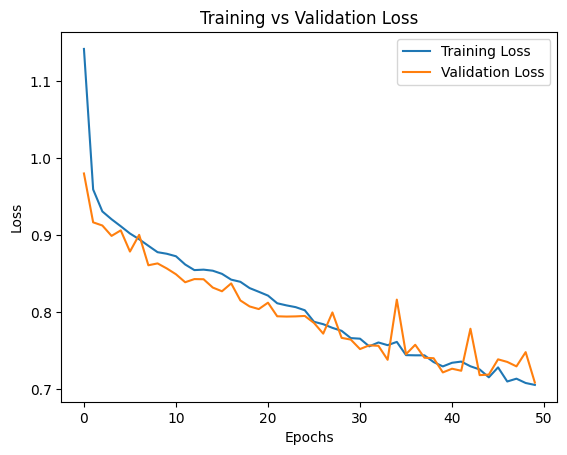


FCNN Results:
Accuracy: 0.6777702243371856
F1 Score: 0.6787641124626697
Confusion Matrix:
 [[180  43  22   0   0   0]
 [ 22 182  11   0   0   0]
 [ 43  18 136   0   0   0]
 [  0   0   0 133  56  68]
 [  0   1   0  86 165  23]
 [  0   1   0  69  11 201]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73       245
           1       0.74      0.85      0.79       215
           2       0.80      0.69      0.74       197
           3       0.46      0.52      0.49       257
           4       0.71      0.60      0.65       275
           5       0.69      0.71      0.70       282

    accuracy                           0.68      1471
   macro avg       0.69      0.68      0.68      1471
weighted avg       0.68      0.68      0.68      1471



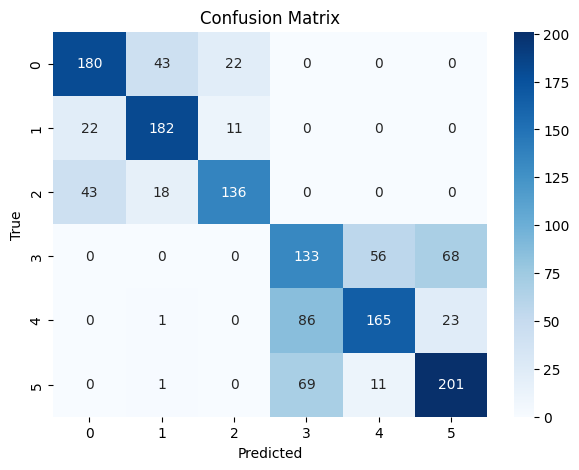

Model saved as fcnn_model.pth


In [4]:
import pandas as pd
import numpy as np
from scipy.fft import fft
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests, zipfile, io


# Download and load UCI HAR dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

# Load features
features = pd.read_csv(
    z.open("UCI HAR Dataset/features.txt"),
    sep=r"\s+", header=None, names=["index", "feature"]
)["feature"].tolist()

# Fix duplicates
counts = Counter(features)
new_features = []
used = {}
for feat in features:
    if counts[feat] == 1:
        new_features.append(feat)
    else:
        used.setdefault(feat, 0)
        new_features.append(f"{feat}_{used[feat]}")
        used[feat] += 1

# Load training data
X_train_raw = pd.read_csv(
    z.open("UCI HAR Dataset/train/X_train.txt"),
    sep=r"\s+", header=None, names=new_features
)
y_train_raw = pd.read_csv(
    z.open("UCI HAR Dataset/train/y_train.txt"),
    sep=r"\s+", header=None, names=["Activity"]
)
subject_train = pd.read_csv(
    z.open("UCI HAR Dataset/train/subject_train.txt"),
    sep=r"\s+", header=None, names=["Subject"]
)


# Feature extraction function
def extract_features(signal):
    signal = np.array(signal)
    features = {}

    # Statistical
    features['mean'] = np.mean(signal)
    features['median'] = np.median(signal)
    features['std'] = np.std(signal)
    features['var'] = np.var(signal)
    features['min'] = np.min(signal)
    features['max'] = np.max(signal)
    features['skew'] = pd.Series(signal).skew()
    features['kurtosis'] = pd.Series(signal).kurt()

    # Temporal
    features['zcr'] = ((signal[:-1]*signal[1:])<0).sum()
    features['energy'] = np.sum(signal**2)
    features['ptp'] = np.ptp(signal)
    features['sma'] = np.sum(np.abs(signal))/len(signal)

    # Frequency
    fft_vals = np.abs(fft(signal))
    fft_norm = fft_vals / np.sum(fft_vals + 1e-10)
    features['spectral_centroid'] = np.sum(np.arange(len(fft_vals))*fft_vals)/np.sum(fft_vals)
    features['spectral_entropy'] = -np.sum(fft_norm * np.log(fft_norm + 1e-10))

    return features


# Extract features for all rows
print("Extracting features...")
feature_rows = []
for i in range(len(X_train_raw)):
    row_signal = X_train_raw.iloc[i]
    feats = extract_features(row_signal)
    feats["label"] = int(y_train_raw.iloc[i].values[0])-1  # 0–5 labels
    feats["subject"] = int(subject_train.iloc[i].values[0])
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print("Feature extraction completed!")
print("Feature DataFrame shape:", features_df.shape)


# Save features to CSV
features_df.to_csv("har_features.csv", index=False)
print("Features saved to har_features.csv")


#  Prepare data for FCNN
X = features_df.drop(columns=["label", "subject"]).values
y = features_df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)


# Define FCNN
class FCNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = FCNN(X_train.shape[1], len(np.unique(y_train)))


# Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

train_losses, val_losses = [], []


# Training Loop
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch}/{num_epochs}] Train Loss: {epoch_loss:.4f} Val Loss: {val_loss:.4f}")


# Plot Loss
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


# Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_val_t)
    y_pred = torch.argmax(outputs, dim=1).numpy()

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average="weighted")
cm = confusion_matrix(y_val, y_pred)

print("\nFCNN Results:")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, y_pred))


#  Plot Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# Save Model
torch.save(model.state_dict(), "fcnn_model.pth")
print("Model saved as fcnn_model.pth")